In [2]:
# 1. Setup & Imports

!pip install mlxtend --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
# 2. Load the refined dataset

DATA_PATH = "merged_common_students.csv"   # make sure this file is in your working dir

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()


Shape: (382, 53)

Columns:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet', 'guardian.x', 'traveltime.x', 'studytime.x', 'failures.x', 'schoolsup.x', 'famsup.x', 'paid.x', 'activities.x', 'higher.x', 'romantic.x', 'famrel.x', 'freetime.x', 'goout.x', 'Dalc.x', 'Walc.x', 'health.x', 'absences.x', 'G1.x', 'G2.x', 'G3.x', 'guardian.y', 'traveltime.y', 'studytime.y', 'failures.y', 'schoolsup.y', 'famsup.y', 'paid.y', 'activities.y', 'higher.y', 'romantic.y', 'famrel.y', 'freetime.y', 'goout.y', 'Dalc.y', 'Walc.y', 'health.y', 'absences.y', 'G1.y', 'G2.y', 'G3.y']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel.y,freetime.y,goout.y,Dalc.y,Walc.y,health.y,absences.y,G1.y,G2.y,G3.y
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,3,1,2,1,1,1,4,13,13,13
1,GP,F,15,R,GT3,T,1,1,other,other,...,3,3,4,2,4,5,2,13,11,11
2,GP,F,15,R,GT3,T,2,2,at_home,other,...,4,3,1,1,1,2,8,14,13,12
3,GP,F,15,R,GT3,T,2,4,services,health,...,4,3,2,1,1,5,2,10,11,10
4,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,2,13,13,13


In [6]:
# 3. Basic exploration

print(df.info())
print("\nDescribe numeric columns:\n")
print(df.describe())

# Check a few important columns
print("\nValue counts for G3.x (Math final):")
print(df["G3.x"].value_counts().sort_index())

print("\nValue counts for G3.y (Portuguese final):")
print(df["G3.y"].value_counts().sort_index())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        382 non-null    object
 1   sex           382 non-null    object
 2   age           382 non-null    int64 
 3   address       382 non-null    object
 4   famsize       382 non-null    object
 5   Pstatus       382 non-null    object
 6   Medu          382 non-null    int64 
 7   Fedu          382 non-null    int64 
 8   Mjob          382 non-null    object
 9   Fjob          382 non-null    object
 10  reason        382 non-null    object
 11  nursery       382 non-null    object
 12  internet      382 non-null    object
 13  guardian.x    382 non-null    object
 14  traveltime.x  382 non-null    int64 
 15  studytime.x   382 non-null    int64 
 16  failures.x    382 non-null    int64 
 17  schoolsup.x   382 non-null    object
 18  famsup.x      382 non-null    object
 19  paid.x  

In [8]:
# 4. Feature engineering / binning

df_prep = df.copy()

# ---- Grades (Math + Portuguese): low / medium / high ----
def bin_grade(g):
    if g <= 9:
        return "low"
    elif g <= 14:
        return "medium"
    else:
        return "high"

# Math (x)
df_prep["G1_math_cat"] = df_prep["G1.x"].apply(bin_grade)
df_prep["G2_math_cat"] = df_prep["G2.x"].apply(bin_grade)
df_prep["G3_math_cat"] = df_prep["G3.x"].apply(bin_grade)

# Portuguese (y)
df_prep["G1_port_cat"] = df_prep["G1.y"].apply(bin_grade)
df_prep["G2_port_cat"] = df_prep["G2.y"].apply(bin_grade)
df_prep["G3_port_cat"] = df_prep["G3.y"].apply(bin_grade)

# ---- Alcohol consumption (Dalc, Walc: 1–5) → very_low, low, medium, high ----
alc_bins   = [0, 1, 2, 3, 5]
alc_labels = ["very_low", "low", "medium", "high"]

df_prep["Dalc_math_cat"] = pd.cut(df_prep["Dalc.x"], bins=alc_bins, labels=alc_labels, right=True)
df_prep["Walc_math_cat"] = pd.cut(df_prep["Walc.x"], bins=alc_bins, labels=alc_labels, right=True)

df_prep["Dalc_port_cat"] = pd.cut(df_prep["Dalc.y"], bins=alc_bins, labels=alc_labels, right=True)
df_prep["Walc_port_cat"] = pd.cut(df_prep["Walc.y"], bins=alc_bins, labels=alc_labels, right=True)

# ---- Study time (1–4) ----
study_bins   = [0, 1, 2, 3, 4]
study_labels = ["very_low", "low", "medium", "high"]

df_prep["studytime_math_cat"] = pd.cut(df_prep["studytime.x"], bins=study_bins, labels=study_labels, right=True)
df_prep["studytime_port_cat"] = pd.cut(df_prep["studytime.y"], bins=study_bins, labels=study_labels, right=True)

# ---- Absences (0–N) → low, medium, high ----
df_prep["absences_math_cat"] = pd.cut(
    df_prep["absences.x"],
    bins=[-1, 5, 15, 200],
    labels=["low", "medium", "high"]
)

df_prep["absences_port_cat"] = pd.cut(
    df_prep["absences.y"],
    bins=[-1, 5, 15, 200],
    labels=["low", "medium", "high"]
)

# ---- Failures (0–3+) ----
def bin_failures(f):
    if f == 0:
        return "0"
    elif f == 1:
        return "1"
    else:
        return ">=2"

df_prep["failures_math_cat"] = df_prep["failures.x"].apply(bin_failures)
df_prep["failures_port_cat"] = df_prep["failures.y"].apply(bin_failures)

# ---- Age → categorical ----
def bin_age(a):
    if a <= 16:
        return "15-16"
    elif a <= 18:
        return "17-18"
    else:
        return "19+"

df_prep["age_cat"] = df_prep["age"].apply(bin_age)

# Quick check:
df_prep[[
    "G1.x","G1_math_cat","G2.x","G2_math_cat","G3.x","G3_math_cat",
    "G1.y","G1_port_cat","G2.y","G2_port_cat","G3.y","G3_port_cat"
]].head()


,G1.x,G1_math_cat,G2.x,G2_math_cat,G3.x,G3_math_cat,G1.y,G1_port_cat,G2.y,G2_port_cat,G3.y,G3_port_cat
0,7,low,10,medium,10,medium,13,medium,13,medium,13,medium
1,8,low,6,low,5,low,13,medium,11,medium,11,medium
2,14,medium,13,medium,13,medium,14,medium,13,medium,12,medium
3,10,medium,9,low,8,low,10,medium,11,medium,10,medium
4,10,medium,10,medium,10,medium,13,medium,13,medium,13,medium


In [10]:
# 5. Select columns for association mining

cols_for_rules = [
    # Demographics / base info
    "school",
    "sex",
    "age_cat",
    "address",
    "famsize",
    "Pstatus",
    "Medu",
    "Fedu",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",

    # Support / activities (if exist in your df)
    "schoolsup.x",
    "famsup.x",
    "paid.x",
    "activities.x",
    "nursery.x",
    "higher.x",
    "internet.x",
    "romantic.x",

    "schoolsup.y",
    "famsup.y",
    "paid.y",
    "activities.y",
    "nursery.y",
    "higher.y",
    "internet.y",
    "romantic.y",

    # Binned academic + behaviour (Math)
    "studytime_math_cat",
    "failures_math_cat",
    "Dalc_math_cat",
    "Walc_math_cat",
    "absences_math_cat",
    "G1_math_cat",
    "G2_math_cat",
    "G3_math_cat",

    # Binned academic + behaviour (Portuguese)
    "studytime_port_cat",
    "failures_port_cat",
    "Dalc_port_cat",
    "Walc_port_cat",
    "absences_port_cat",
    "G1_port_cat",
    "G2_port_cat",
    "G3_port_cat",
]

# Keep only the columns that actually exist (in case any name mismatch)
cols_for_rules = [c for c in cols_for_rules if c in df_prep.columns]

df_rules = df_prep[cols_for_rules].copy()
df_rules.head()


,school,sex,age_cat,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G2_math_cat,G3_math_cat,studytime_port_cat,failures_port_cat,Dalc_port_cat,Walc_port_cat,absences_port_cat,G1_port_cat,G2_port_cat,G3_port_cat
0,GP,F,15-16,R,GT3,T,1,1,at_home,other,...,medium,medium,high,0,very_low,very_low,low,medium,medium,medium
1,GP,F,15-16,R,GT3,T,1,1,other,other,...,low,low,low,0,low,high,low,medium,medium,medium
2,GP,F,15-16,R,GT3,T,2,2,at_home,other,...,medium,medium,very_low,0,very_low,very_low,medium,medium,medium,medium
3,GP,F,15-16,R,GT3,T,2,4,services,health,...,low,low,medium,0,very_low,very_low,low,medium,medium,medium
4,GP,F,15-16,R,GT3,T,3,3,services,services,...,medium,medium,medium,0,low,medium,low,medium,medium,medium


In [14]:
# 6. Convert to one-hot encoded (transaction) format

df_rules = df_rules.astype(str)  # ensure everything is string/categorical

df_ohe = pd.get_dummies(df_rules)

print("One-hot encoded shape:", df_ohe.shape)
df_ohe.head()


One-hot encoded shape: (382, 115)


,school_GP,school_MS,sex_F,sex_M,age_cat_15-16,age_cat_17-18,age_cat_19+,address_R,address_U,famsize_GT3,...,absences_port_cat_medium,G1_port_cat_high,G1_port_cat_low,G1_port_cat_medium,G2_port_cat_high,G2_port_cat_low,G2_port_cat_medium,G3_port_cat_high,G3_port_cat_low,G3_port_cat_medium
0,True,False,True,False,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,True
1,True,False,True,False,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,True
2,True,False,True,False,True,False,False,True,False,True,...,True,False,False,True,False,False,True,False,False,True
3,True,False,True,False,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,True
4,True,False,True,False,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,True


In [16]:
# 7. Run Apriori (with built-in filtering)

# --- drop very rare dummy columns first ---
min_col_support = 0.03      # column must be 3% '1' to be kept
row_count = len(df_ohe)

cols_to_keep = [
    c for c in df_ohe.columns
    if df_ohe[c].sum() >= min_col_support * row_count
]
df_ohe_reduced = df_ohe[cols_to_keep]

print("Original columns:", df_ohe.shape[1])
print("Reduced columns:", df_ohe_reduced.shape[1])

# --- run Apriori on the reduced matrix ---
frequent_itemsets = apriori(
    df_ohe_reduced,
    min_support=0.10,   # appears in at least 10% of students
    use_colnames=True,
    max_len=2           # only 1- and 2-itemsets to keep runtime small
)

# add length of itemsets
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# filter again for safety
frequent_itemsets = frequent_itemsets[
    (frequent_itemsets["length"] <= 2) &
    (frequent_itemsets["support"] >= 0.10)
].copy()

print("Number of frequent itemsets after filtering:", len(frequent_itemsets))
frequent_itemsets.sort_values("support", ascending=False).head(10)


Original columns: 115
Reduced columns: 113
Number of frequent itemsets after filtering: 2440


,support,itemsets,length
36,0.952880,(higher.x_yes),1
46,0.952880,(higher.y_yes),1
1612,0.947644,"(higher.y_yes, higher.x_yes)",2
43,0.931937,(paid.y_no),1
73,0.910995,(failures_port_cat_0),1
10,0.900524,(Pstatus_T),1
0,0.895288,(school_GP),1
1860,0.887435,"(higher.y_yes, paid.y_no)",2
1609,0.887435,"(higher.x_yes, paid.y_no)",2
1995,0.882199,"(higher.y_yes, failures_port_cat_0)",2


In [18]:
# 8. Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6    # minimum confidence 60%
)

rules_sorted = rules.sort_values(["lift", "confidence"], ascending=False)

print("Number of rules:", len(rules_sorted))
rules_sorted.head(10)


Number of rules: 1866


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
902,(schoolsup.y_yes),(schoolsup.x_yes),0.130890,0.133508,0.128272,0.980000,7.340392,1.0,0.110797,43.324607,0.993853,0.942308,0.976918,0.970392
903,(schoolsup.x_yes),(schoolsup.y_yes),0.133508,0.130890,0.128272,0.960784,7.340392,1.0,0.110797,22.162304,0.996856,0.942308,0.954878,0.970392
1540,(studytime_math_cat_medium),(studytime_port_cat_medium),0.162304,0.164921,0.157068,0.967742,5.867896,1.0,0.130301,25.887435,0.990313,0.923077,0.961371,0.960061
1539,(studytime_port_cat_medium),(studytime_math_cat_medium),0.164921,0.162304,0.157068,0.952381,5.867896,1.0,0.130301,17.591623,0.993417,0.923077,0.943155,0.960061
1735,(G2_math_cat_high),(G3_math_cat_high),0.180628,0.193717,0.178010,0.985507,5.087348,1.0,0.143020,55.633508,0.980549,0.906667,0.982025,0.952213
1734,(G3_math_cat_high),(G2_math_cat_high),0.193717,0.180628,0.178010,0.918919,5.087348,1.0,0.143020,10.105585,0.996467,0.906667,0.901045,0.952213
1600,(Dalc_math_cat_low),(Dalc_port_cat_low),0.191099,0.193717,0.185864,0.972603,5.020733,1.0,0.148845,29.429319,0.990018,0.934211,0.966020,0.966031
1601,(Dalc_port_cat_low),(Dalc_math_cat_low),0.193717,0.191099,0.185864,0.959459,5.020733,1.0,0.148845,19.952880,0.993232,0.934211,0.949882,0.966031
1657,(Walc_port_cat_medium),(Walc_math_cat_medium),0.198953,0.198953,0.196335,0.986842,4.960180,1.0,0.156753,60.879581,0.996688,0.974026,0.983574,0.986842
1658,(Walc_math_cat_medium),(Walc_port_cat_medium),0.198953,0.198953,0.196335,0.986842,4.960180,1.0,0.156753,60.879581,0.996688,0.974026,0.983574,0.986842


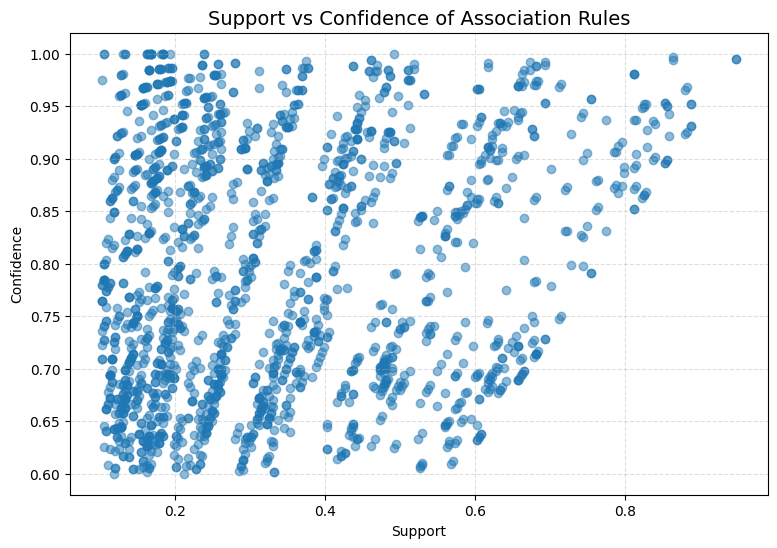

In [24]:
# Plot 1: Support vs Confidence (all rules)

plt.figure(figsize=(9, 6))
plt.scatter(rules_sorted["support"], rules_sorted["confidence"], alpha=0.5)
plt.title("Support vs Confidence of Association Rules", fontsize=14)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


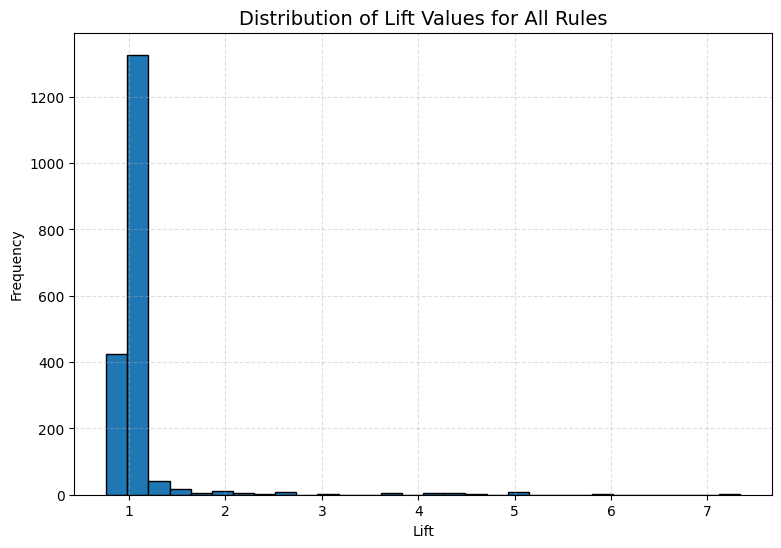

In [28]:
# Plot 2: Distribution of Lift values

plt.figure(figsize=(9, 6))
plt.hist(rules_sorted["lift"], bins=30, edgecolor="black")
plt.title("Distribution of Lift Values for All Rules", fontsize=14)
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [20]:
# 9a. Rules where consequent involves Math final grade (G3_math_cat)

def has_G3_math(row):
    return any("G3_math_cat" in str(item) for item in row["consequents"])

rules_G3_math = rules_sorted[rules_sorted.apply(has_G3_math, axis=1)].copy()

rules_G3_math[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)


,antecedents,consequents,support,confidence,lift
1735,(G2_math_cat_high),(G3_math_cat_high),0.178010,0.985507,5.087348
1708,(G1_math_cat_high),(G3_math_cat_high),0.143979,0.859375,4.436233
1741,(G2_math_cat_low),(G3_math_cat_low),0.308901,0.819444,2.464786
1765,(G2_port_cat_low),(G3_math_cat_low),0.102094,0.722222,2.172353
1717,(G1_math_cat_low),(G3_math_cat_low),0.261780,0.714286,2.148481
1751,(G2_math_cat_medium),(G3_math_cat_medium),0.403141,0.911243,1.923175
1726,(G1_math_cat_medium),(G3_math_cat_medium),0.345550,0.741573,1.565088


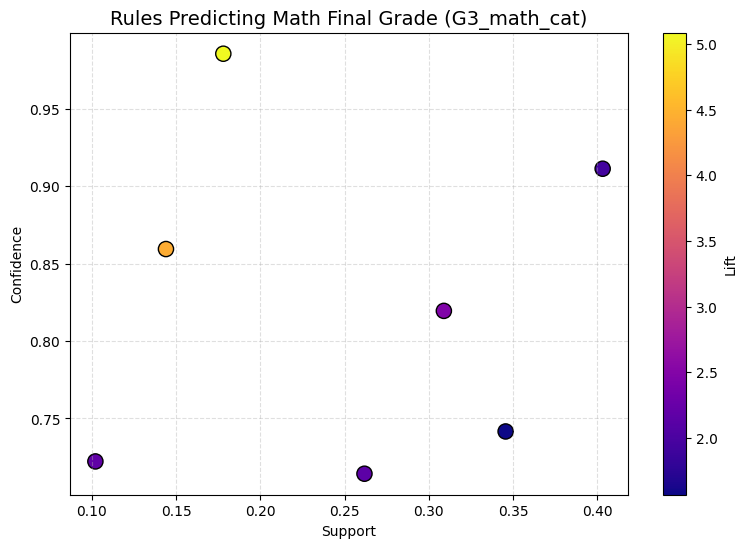

In [30]:
# Plot 3: Rules predicting Math final grade (G3_math_cat)

plt.figure(figsize=(9, 6))
plt.scatter(
    rules_G3_math["support"],
    rules_G3_math["confidence"],
    c=rules_G3_math["lift"],
    cmap="plasma",
    s=120,
    edgecolor="black"
)
plt.colorbar(label="Lift")
plt.title("Rules Predicting Math Final Grade (G3_math_cat)", fontsize=14)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [22]:
# 9b. Rules where consequent involves Portuguese final grade (G3_port_cat)

def has_G3_port(row):
    return any("G3_port_cat" in str(item) for item in row["consequents"])

rules_G3_port = rules_sorted[rules_sorted.apply(has_G3_port, axis=1)].copy()

rules_G3_port[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)


,antecedents,consequents,support,confidence,lift
1862,(G2_port_cat_high),(G3_port_cat_high),0.180628,0.985714,4.137834
1856,(G1_port_cat_high),(G3_port_cat_high),0.151832,0.906250,3.804258
1713,(G1_math_cat_high),(G3_port_cat_high),0.107330,0.640625,2.689217
1739,(G2_math_cat_high),(G3_port_cat_high),0.109948,0.608696,2.555184
1277,(schoolsup.y_yes),(G3_port_cat_medium),0.117801,0.900000,1.327413
1865,(G2_port_cat_medium),(G3_port_cat_medium),0.607330,0.899225,1.326270
912,(schoolsup.x_yes),(G3_port_cat_medium),0.117801,0.882353,1.301385
1861,(G1_port_cat_medium),(G3_port_cat_medium),0.589005,0.855513,1.261800
1723,(G1_math_cat_low),(G3_port_cat_medium),0.290576,0.792857,1.169388
1749,(G2_math_cat_low),(G3_port_cat_medium),0.293194,0.777778,1.147147


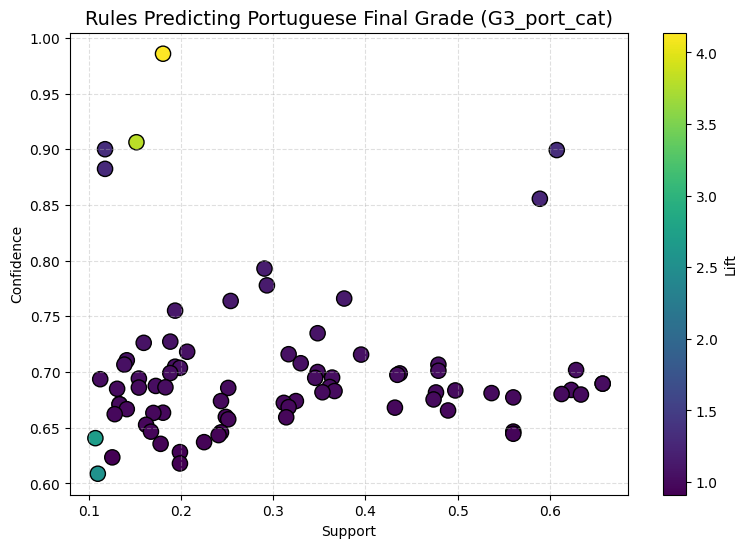

In [32]:
# Plot 4: Rules predicting Portuguese final grade (G3_port_cat)

plt.figure(figsize=(9, 6))
plt.scatter(
    rules_G3_port["support"],
    rules_G3_port["confidence"],
    c=rules_G3_port["lift"],
    cmap="viridis",
    s=120,
    edgecolor="black"
)
plt.colorbar(label="Lift")
plt.title("Rules Predicting Portuguese Final Grade (G3_port_cat)", fontsize=14)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
